# Desafío 2  

## Analistes del Perfil del Client : Quines diferències hi ha en el comportament financer entre els diferents segments demogràfics, i com podem utilitzar aquesta informació per personalitzar les nostres ofertes?

En este análisis se desarrolla una segmentación del perfil del cliente a partir de variables estrictamente demográficas —edad, estado civil, ocupación y nivel educativo— utilizando técnicas de clustering no supervisado. El objetivo inicial es identificar grupos homogéneos de clientes que compartan características sociodemográficas similares y que, por tanto, puedan considerarse segmentos naturales dentro de la base de datos.  

Una vez definidos estos segmentos, el estudio avanza hacia la dimensión financiera, cruzando cada cluster con el comportamiento económico de los clientes: tenencia de depósitos, préstamos y productos hipotecarios. Este cruce permite observar cómo las diferencias demográficas se traducen en patrones financieros diferenciados.  

Finalmente, se incorpora la variable balance (saldo medio y mediano), que actúa como indicador de liquidez y riesgo financiero. Esta última capa completa el perfil de cada segmento y permite evaluar no solo qué productos utilizan, sino también su capacidad económica y su estabilidad financiera.  

En conjunto, este enfoque permite responder a la pregunta central del análisis:
qué diferencias existen en el comportamiento financiero entre los distintos segmentos demográficos y cómo puede utilizarse esta información para personalizar las ofertas y estrategias comerciales.


*Librerías*

In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes

In [3]:
# Conexión a MySQL
conexion = mysql.connector.connect(
    host="212.227.90.6",      
    user="Equipo21",     
    password="E1q2u3i4p5o21",
    database="Equip_21"
)

# Comprobamos la conexión
if conexion.is_connected():
    print("✅ Conectado a MySQL correctamente")

✅ Conectado a MySQL correctamente


In [4]:
df = pd.read_sql("SELECT * FROM BANK_marketing;", conexion)
df

C:\Users\titan\AppData\Local\Temp\ipykernel_29044\2141821518.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM BANK_marketing;", conexion)


,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
1,2,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
2,69,40,services,married,primary,0,-9,1,0,low_quality,15,may,920,2,-1,0,unknown,1
3,3,56,admin.,married,secondary,0,45,0,0,low_quality,5,may,1467,1,-1,0,unknown,1
4,4,41,technician,married,secondary,0,1270,1,0,low_quality,5,may,1389,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10993,10935,47,blue-collar,married,secondary,0,2548,1,0,cellular,11,may,577,1,368,1,other,0
10994,10936,31,services,single,secondary,0,3,1,0,cellular,5,may,41,1,-1,0,unknown,0
10995,10937,40,admin.,married,secondary,0,1395,1,1,cellular,7,jul,122,2,-1,0,unknown,0
10996,10938,28,blue-collar,married,primary,0,-196,0,0,cellular,7,jul,209,1,-1,0,unknown,0


In [5]:
X = df[['age', 'balance','job', 'education', 'marital']]

In [6]:
categorical_columns = [1, 2, 3, 4]  # Índices de las columnas categóricas

In [7]:
kproto = KPrototypes(
    n_clusters=4,
    init='Cao',
    n_init=10,
    random_state=42
)

clusters = kproto.fit_predict(X, categorical=categorical_columns)
df['cluster_kproto'] = clusters
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,cluster_kproto
0,1,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1,2
1,2,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1,2
2,69,40,services,married,primary,0,-9,1,0,low_quality,15,may,920,2,-1,0,unknown,1,1
3,3,56,admin.,married,secondary,0,45,0,0,low_quality,5,may,1467,1,-1,0,unknown,1,2
4,4,41,technician,married,secondary,0,1270,1,0,low_quality,5,may,1389,1,-1,0,unknown,1,1


In [9]:
Perfil_socio= df.groupby('cluster_kproto').agg(
    total_id=('id', 'count'),
    median_age=('age', 'median'),
    job=('job', lambda x: x.value_counts().idxmax()),
    marital=('marital', lambda x: x.value_counts().idxmax()),
    education=('education', lambda x: x.value_counts().idxmax())
)
Perfil_socio.head()

,total_id,median_age,job,marital,education
cluster_kproto,,,,,
0,461,72.0,retired,married,primary
1,3402,42.0,management,married,secondary
2,2409,55.0,management,married,secondary
3,4726,31.0,management,single,secondary


El proceso de clustering aplicado sobre las variables demográficas permitió identificar cuatro segmentos dentro de la base de clientes. Cada cluster presenta un perfil sociodemográfico :  

- Cluster 0 – Seniors
Grupo reducido en tamaño, con una edad mediana de 72 años, mayoritariamente jubilados, casados y con bajo nivel educativo.  

- Cluster 1 – Adultos jóvenes
Segmento numeroso, con edad mediana de 42 años, predominantemente en puestos de management, casados y con educación secundaria.  

- Cluster 2 – Adultos maduros
Grupo intermedio, con edad mediana de 55 años, también con perfiles laborales de management, casados y con educación secundaria.  

- Cluster 3 – Jóvenes
El segmento más numeroso, con edad mediana de 31 años, mayoritariamente solteros, con educación secundaria y ocupaciones de management.  
Por qué la edad emerge como variable diferencial clave  



la edad se revela como el eje estructural que organiza los segmentos. 

La edad sintetiza etapas vitales
Cada tramo de edad está asociado a patrones de vida distintos:
- inicio laboral
- formación de hogar
- consolidación económica
- retiro

C:\Users\titan\AppData\Local\Temp\ipykernel_29044\1883519003.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


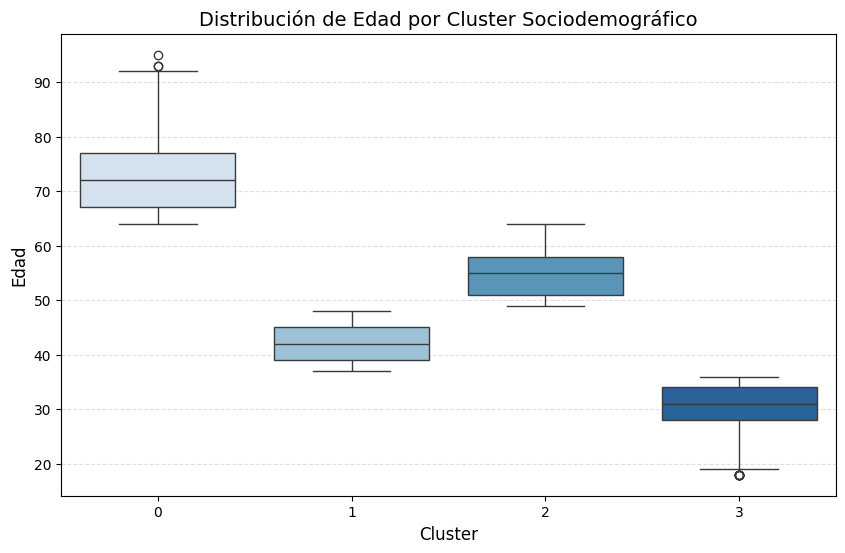

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='cluster_kproto',
    y='age',
    palette='Blues'
)

plt.title('Distribución de edad por cluster Sociodemográfico', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Edad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

**Observación**

El boxplot muestra una separación clara entre los cuatro clusters sociodemográficos.
La baja superposición entre cajas confirma que la edad es el principal eje de segmentación del modelo.



In [11]:
perfil_fin_media = (
    df
    .groupby('cluster_kproto')[['deposit', 'loan', 'housing']]
    .mean()
    .rename(columns={
        'deposit': 'deposit_mean',
        'loan': 'loan_mean',
        'housing': 'housing_mean'
    })
)
perfil_fin_media.head()

,deposit_mean,loan_mean,housing_mean
cluster_kproto,,,
0,0.813449,0.006508,0.047722
1,0.417695,0.138742,0.540858
2,0.461187,0.139892,0.376090
3,0.504867,0.131401,0.512696


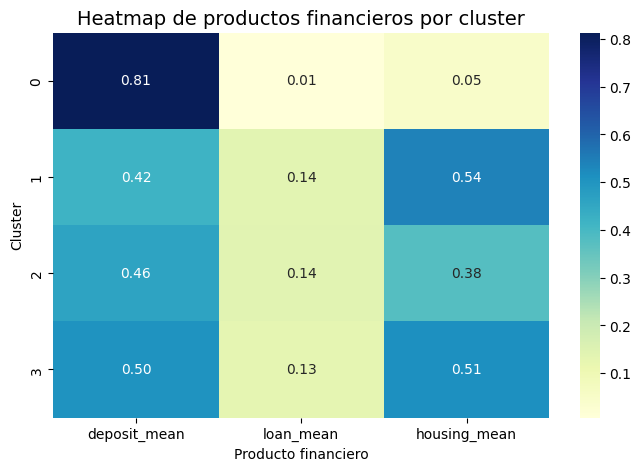

In [26]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    perfil_fin_media,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Heatmap de productos financieros por cluster', fontsize=14)
plt.xlabel('Producto financiero')
plt.ylabel('Cluster')
plt.show()

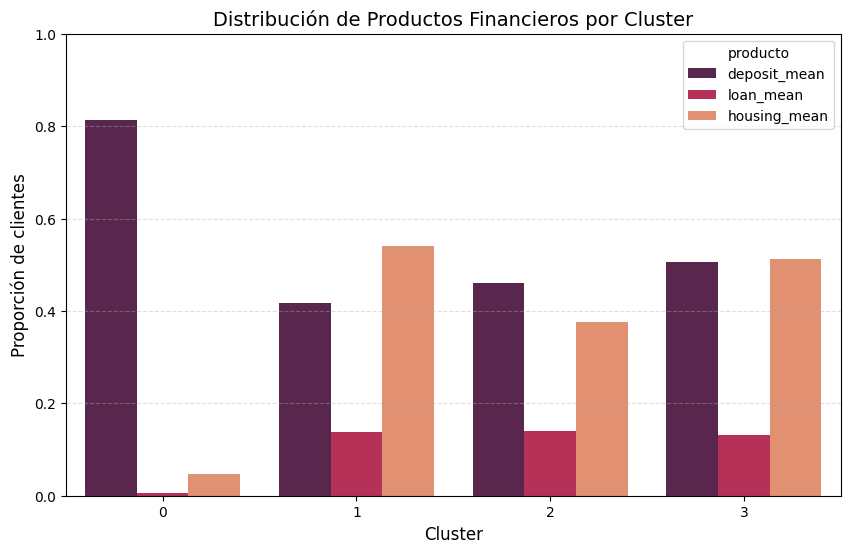

In [29]:

# Preparamos los datos en formato largo
perfil_fin_long = perfil_fin_media.reset_index().melt(
    id_vars='cluster_kproto',
    value_vars=['deposit_mean', 'loan_mean', 'housing_mean'],
    var_name='producto',
    value_name='proporcion'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_fin_long,
    x='cluster_kproto',
    y='proporcion',
    hue='producto',
    palette='rocket'
)

plt.title('Distribución de Productos Financieros por Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Proporción de clientes', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

- La edad estructura el comportamiento financiero.
Los seniors son ahorradores, los adultos jóvenes están endeudados, los maduros equilibrados y los jóvenes con hipoteca y liquidez baja.
- Los depósitos son un producto generacional.
Su uso cae drásticamente a medida que baja la edad.
- La hipoteca es el producto más diferenciador entre clusters.
Los clusters 1 y 3 concentran la mayor carga hipotecaria.
- Los préstamos personales son bajos en todos los segmentos.


In [12]:
perfil_balance = (
    df
    .groupby('cluster_kproto')
    .agg(
        balance_mean=('balance', 'mean'),
        balance_median=('balance', 'median')
    )
)
perfil_balance.head()

,balance_mean,balance_median
cluster_kproto,,
0,2837.585683,1492.0
1,1481.958554,558.0
2,1869.412619,660.0
3,1280.767668,468.5


In [13]:
perfil_final_kproto = (
    Perfil_socio
    .join(perfil_balance)
    .join(perfil_fin_media)
)
perfil_final_kproto.head()

,total_id,median_age,job,marital,education,balance_mean,balance_median,deposit_mean,loan_mean,housing_mean
cluster_kproto,,,,,,,,,,
0,461,72.0,retired,married,primary,2837.585683,1492.0,0.813449,0.006508,0.047722
1,3402,42.0,management,married,secondary,1481.958554,558.0,0.417695,0.138742,0.540858
2,2409,55.0,management,married,secondary,1869.412619,660.0,0.461187,0.139892,0.376090
3,4726,31.0,management,single,secondary,1280.767668,468.5,0.504867,0.131401,0.512696


In [38]:
bins = [17, 25, 30, 35, 45, 50, 55, 60, 65, 120]
labels = [
    '18-25',
    '26-30',
    '31-35',
    '36-45',
    '46-50',
    '51-55',
    '56-60',
    '61-65',
    '65+'
]

perfil_final_kproto['age_cat'] = pd.cut(perfil_final_kproto['median_age'], bins=bins, labels=labels)

#perfil_final.plot(kind='hist', y='age', bins=30, title='Distribución de Edad',grid=True, figsize=(8,5), color='skyblue')

perfil_final_kproto.head()

,total_id,median_age,job,marital,education,balance_mean,balance_median,deposit_mean,loan_mean,housing_mean,age_cat,balance_segment
cluster_kproto,,,,,,,,,,,,
0,461,72.0,retired,married,primary,2837.585683,1492.0,0.813449,0.006508,0.047722,65+,alto
1,3402,42.0,management,married,secondary,1481.958554,558.0,0.417695,0.138742,0.540858,36-45,bajo
2,2409,55.0,management,married,secondary,1869.412619,660.0,0.461187,0.139892,0.376090,51-55,medio
3,4726,31.0,management,single,secondary,1280.767668,468.5,0.504867,0.131401,0.512696,31-35,bajo


In [39]:
perfil_final_kproto["balance_segment"] = np.nan

#Segmento negativo
perfil_final_kproto.loc[perfil_final_kproto["balance_median"] < 0, "balance_segment"] = "negativo" # Tener un saldo negativo implica estar en descubierto, 
                                                          # indicador grave de estrés económico por lo que el riesgo es muu alto.

#Segmento cero + positivo (agrupamos los saldo 0 con los positivos ya que consideramos que tener 0 saldo no supone un riesgo en sí mismo,
#pese a que no sea un indicador de solvencia fuerte.)
non_negative_mask = perfil_final_kproto["balance_median"] >= 0

#Subsegmentar cero y positivos en tres grupos
perfil_final_kproto.loc[non_negative_mask, "balance_segment"] = pd.qcut(
    perfil_final_kproto.loc[non_negative_mask, "balance_median"],
    q=3,
    labels=["bajo", "medio", "alto"])
perfil_final_kproto.head()

C:\Users\titan\AppData\Local\Temp\ipykernel_29044\899912849.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'negativo' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perfil_final_kproto.loc[perfil_final_kproto["balance_median"] < 0, "balance_segment"] = "negativo" # Tener un saldo negativo implica estar en descubierto,


,total_id,median_age,job,marital,education,balance_mean,balance_median,deposit_mean,loan_mean,housing_mean,age_cat,balance_segment
cluster_kproto,,,,,,,,,,,,
0,461,72.0,retired,married,primary,2837.585683,1492.0,0.813449,0.006508,0.047722,65+,alto
1,3402,42.0,management,married,secondary,1481.958554,558.0,0.417695,0.138742,0.540858,36-45,bajo
2,2409,55.0,management,married,secondary,1869.412619,660.0,0.461187,0.139892,0.376090,51-55,medio
3,4726,31.0,management,single,secondary,1280.767668,468.5,0.504867,0.131401,0.512696,31-35,bajo


**- Cluster 0 (Seniors 65+)**  

Clientes mayores, casados, jubilados, con alta liquidez y fuerte preferencia por depósitos.  

**- Cluster 1 (36–45)**  

Adultos jóvenes, casados, con hipoteca, liquidez baja y uso moderado de préstamos.  

**- Cluster 2 (46–55)**  

Adultos maduros, casados, con liquidez media-alta y comportamiento financiero estable.  

**- Cluster 3 (31–35)**  

Jóvenes profesionales, solteros, con hipoteca y liquidez baja.


In [51]:
nombres_clusters = {
    0: 'Seniors',
    1: 'Adultos jóvenes',
    2: 'Adultos maduros',
    3: 'Jóvenes'
}

perfil_final_kproto['cluster_nombre'] = perfil_final_kproto.index.map(nombres_clusters)

nombres_estrategicos = {
    0: 'Conservadores líquidos',
    1: 'Constructores de patrimonio',
    2: 'Consolidadores',
    3: 'Emergentes'
}

perfil_final_kproto['cluster_estrategico'] = perfil_final_kproto.index.map(nombres_estrategicos)

perfil_final_kproto

,total_id,median_age,job,marital,education,balance_mean,balance_median,deposit_mean,loan_mean,housing_mean,age_cat,balance_segment,cluster_nombre,cluster_estrategico
cluster_kproto,,,,,,,,,,,,,,
0,461,72.0,retired,married,primary,2837.585683,1492.0,0.813449,0.006508,0.047722,65+,alto,Seniors,Conservadores líquidos
1,3402,42.0,management,married,secondary,1481.958554,558.0,0.417695,0.138742,0.540858,36-45,bajo,Adultos jóvenes,Constructores de patrimonio
2,2409,55.0,management,married,secondary,1869.412619,660.0,0.461187,0.139892,0.376090,51-55,medio,Adultos maduros,Consolidadores
3,4726,31.0,management,single,secondary,1280.767668,468.5,0.504867,0.131401,0.512696,31-35,bajo,Jóvenes,Emergentes


Para facilitar la interpretación de los clusters y convertirlos en perfiles accionables, se asignaron nombres descriptivos que combinan la etapa vital con el comportamiento financiero (liquidez, deuda y uso de productos). Esta doble lectura permite transformar un resultado técnico de clustering en segmentos comprensibles y útiles para la toma de decisiones comerciales.


Cluster 0 — Seniors → Conservadores líquidos
- Edad 72
- Balance alto
- Depósitos altísimos
- Casi sin deuda
→ Perfil de cliente senior con liquidez y aversión al riesgo.  

Cluster 1 — Adultos jóvenes → Constructores de patrimonio
- Edad 42
- Hipoteca alta
- Liquidez baja
- Casados
→ Etapa vital de construcción familiar y financiera.  

Cluster 2 — Adultos maduros → Consolidadores
- Edad 55
- Liquidez media-alta
- Menos hipoteca
→ Etapa de estabilidad y consolidación patrimonial.  

Cluster 3 — Jóvenes → Emergentes
- Edad 31
- Hipoteca alta
- Liquidez baja
- Solteros
→ Inicio de vida financiera, potencial de crecimiento.


### Visualizaciones

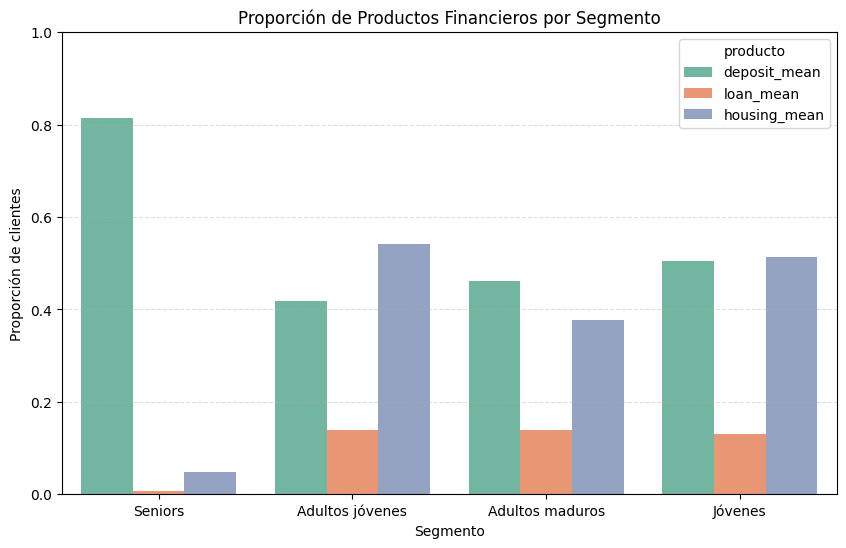

In [ ]:


perfil_fin_long = perfil_final_kproto.reset_index().melt(
    id_vars='cluster_nombre',
    value_vars=['deposit_mean', 'loan_mean', 'housing_mean'],
    var_name='producto',
    value_name='proporcion'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_fin_long,
    x='cluster_nombre',
    y='proporcion',
    hue='producto',
    palette='Set2'
)

plt.title('Proporción de Productos Financieros por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Proporción de clientes')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

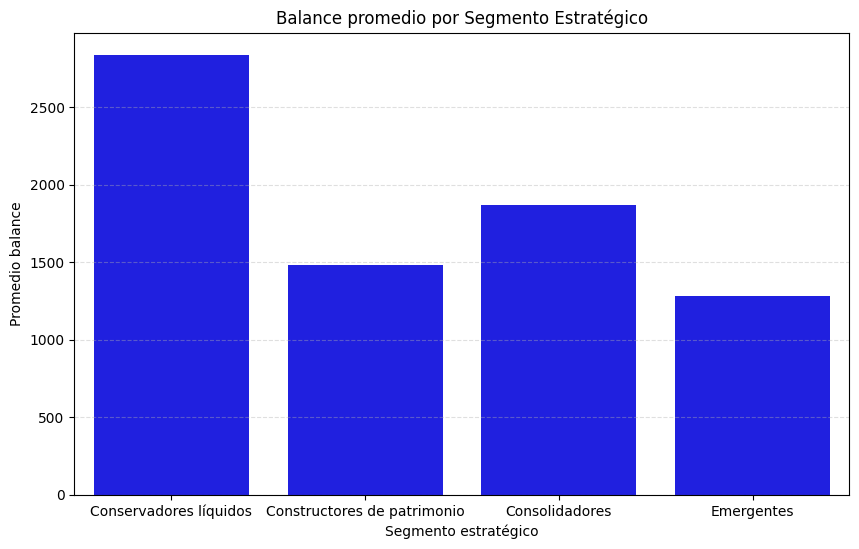

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_final_kproto.reset_index(),
    x='cluster_estrategico',
    y='balance_mean',
   color ='blue'
)

plt.title('Balance promedio por Segmento Estratégico')
plt.xlabel('Segmento estratégico')
plt.ylabel('Promedio balance')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

C:\Users\titan\AppData\Local\Temp\ipykernel_29044\913055538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


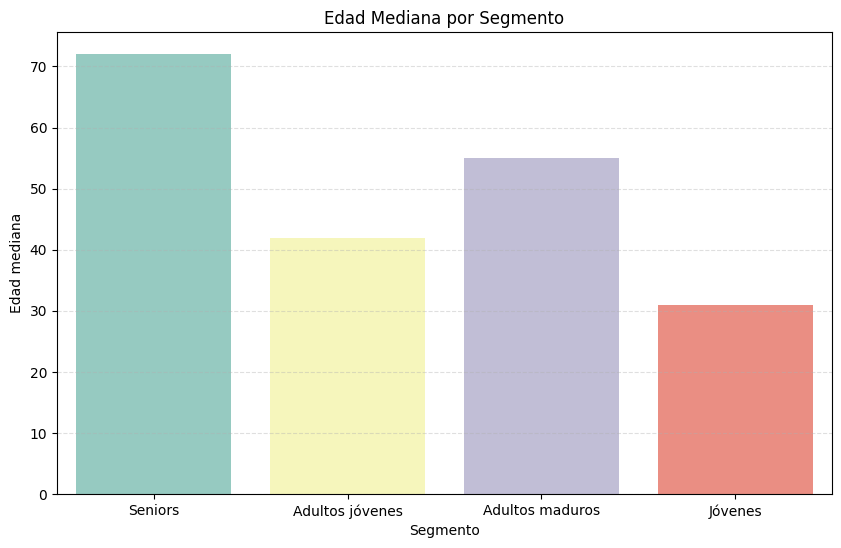

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_final_kproto.reset_index(),
    x='cluster_nombre',
    y='median_age',
    palette='Set3'
)

plt.title('Edad Mediana por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Edad mediana')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

C:\Users\titan\AppData\Local\Temp\ipykernel_29044\3989210746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


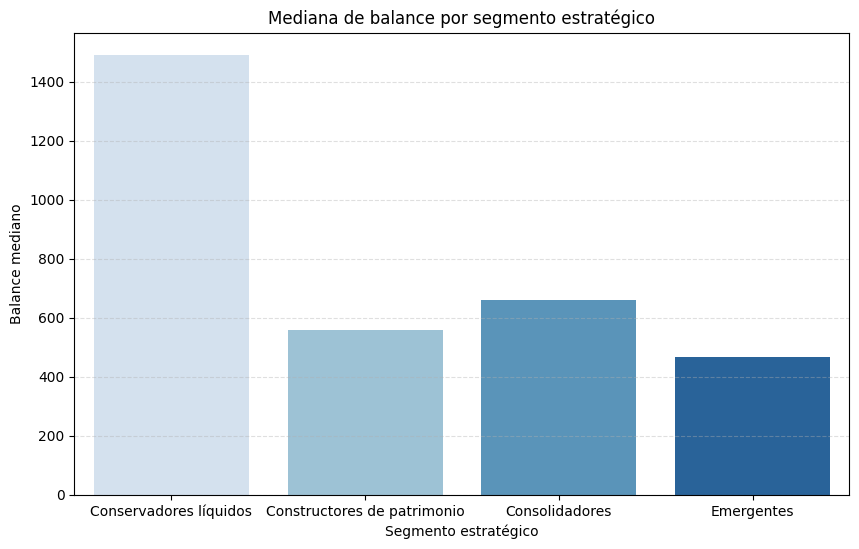

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_final_kproto.reset_index(),
    x='cluster_estrategico',
    y='balance_median',
    palette='Blues'
)

plt.title('Mediana de balance por segmento estratégico')
plt.xlabel('Segmento estratégico')
plt.ylabel('Balance mediano')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

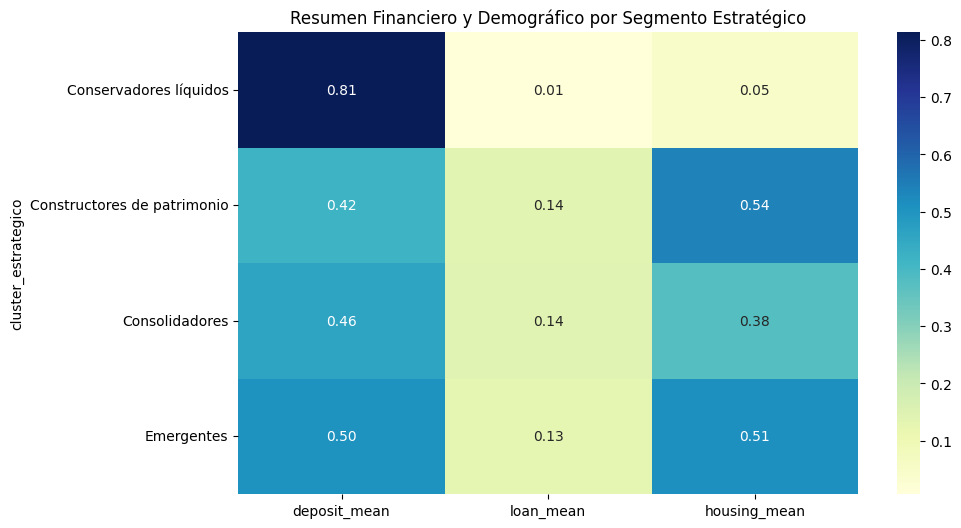

In [62]:
plt.figure(figsize=(10, 6))

cols = [
    #'balance_median',
    'deposit_mean',
    'loan_mean',
    'housing_mean'
]

sns.heatmap(
    perfil_final_kproto.set_index('cluster_estrategico')[cols],
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Resumen Financiero y Demográfico por Segmento Estratégico')
plt.show()

### Observación

La segmentación demográfica realizada mediante técnicas de clustering permitió identificar cuatro perfiles de clientes bien diferenciados, estructurados principalmente por la edad y las etapas vitales asociadas. Al cruzar estos segmentos con las variables financieras —tenencia de depósitos, préstamos e hipotecas— y con los niveles de liquidez medidos a través del balance, se evidencian patrones de comportamiento económico claramente diferenciados entre grupos.
Los Seniors destacan por su elevada liquidez y preferencia por productos de ahorro; los Adultos jóvenes muestran un uso intensivo de hipotecas y menor capacidad de ahorro; los Adultos maduros presentan estabilidad financiera y un comportamiento equilibrado; y los Jóvenes se caracterizan por baja liquidez y un perfil emergente con potencial de crecimiento.
Estos resultados permiten comprender cómo las características demográficas influyen en las necesidades y comportamientos financieros, y ofrecen una base sólida para personalizar ofertas, ajustar estrategias comerciales y diseñar propuestas de valor específicas para cada segmento


### TEST 
**¿Hay diferencias significativas en el comportamiento financiero entre los distintos segmentos demográficos definidos por los clusters?**



🔹Hipótesis nula (H₀)

No existen diferencias estadísticamente significativas en el comportamiento financiero (balance, contratación de depósitos, préstamos e hipotecas) entre los distintos segmentos demográficos definidos por los clusters.

🔹 Hipótesis alternativa (H₁)

Existen diferencias estadísticamente significativas en el comportamiento financiero entre al menos dos de los segmentos demográficos definidos por los clusters.

In [66]:
nombres_clusters = {
    0: 'Seniors',
    1: 'Adultos jóvenes',
    2: 'Adultos maduros',
    3: 'Jóvenes'
}

df['cluster_nombre'] = df['cluster_kproto'].map(nombres_clusters)

nombres_estrategicos = {
    0: 'Conservadores líquidos',
    1: 'Constructores de patrimonio',
    2: 'Consolidadores',
    3: 'Emergentes'
}

df['cluster_estrategico'] = df['cluster_kproto'].map(nombres_estrategicos)


In [67]:
df[['cluster_kproto', 'cluster_nombre', 'cluster_estrategico']].head()


,cluster_kproto,cluster_nombre,cluster_estrategico
0,2,Adultos maduros,Consolidadores
1,2,Adultos maduros,Consolidadores
2,1,Adultos jóvenes,Constructores de patrimonio
3,2,Adultos maduros,Consolidadores
4,1,Adultos jóvenes,Constructores de patrimonio


In [68]:
from scipy.stats import kruskal

groups = [
    df[df['cluster_nombre'] == c]['balance']
    for c in df['cluster_nombre'].unique()
]

stat, p_value = kruskal(*groups)

print(f"Estadístico: {stat}")
print(f"p-value: {p_value}")


Estadístico: 192.5734009422047
p-value: 1.6970452510531357e-41


In [71]:

groups = [
    df[df['cluster_nombre'] == c]['loan']
    for c in df['cluster_nombre'].unique()
]

stat, p_value = kruskal(*groups)

print(f"Estadístico: {stat}")
print(f"p-value: {p_value}")

Estadístico: 66.4825821251419
p-value: 2.416438755292854e-14


In [72]:

groups = [
    df[df['cluster_nombre'] == c]['deposit']
    for c in df['cluster_nombre'].unique()
]

stat, p_value = kruskal(*groups)

print(f"Estadístico: {stat}")
print(f"p-value: {p_value}")

Estadístico: 273.2428886141362
p-value: 6.135583867701474e-59


In [73]:

groups = [
    df[df['cluster_nombre'] == c]['housing']
    for c in df['cluster_nombre'].unique()
]

stat, p_value = kruskal(*groups)

print(f"Estadístico: {stat}")
print(f"p-value: {p_value}")

Estadístico: 517.98848163089
p-value: 6.027906293236653e-112


  Sí, existen diferencias estadísticamente significativas en el comportamiento financiero entre los distintos segmentos demográficos definidos por los clusters.  


  Los tests de Kruskal-Wallis aplicados a las variables balance, depósitos, préstamos e hipotecas arrojan p-values muy inferiores a 0.05, lo que permite rechazar la hipótesis nula en todos los casos.  

  Dado que los p-values obtenidos en todos los contrastes son inferiores al nivel de significación del 5%, se rechaza la hipótesis nula y se acepta la hipótesis alternativa.

<Figure size 640x480 with 0 Axes>

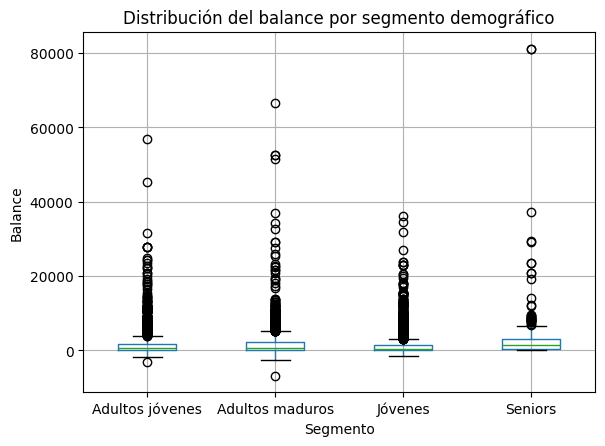

In [70]:
plt.figure()
df.boxplot(
    column='balance',
    by='cluster_nombre'
)

plt.title('Distribución del balance por segmento demográfico')
plt.suptitle('')  # elimina título automático
plt.xlabel('Segmento')
plt.ylabel('Balance')

plt.show()

In [74]:
perfil_final_kproto.to_excel("perfil_final.xlsx", index=True)